In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram, linkage

In [2]:
X, y = make_blobs(
    n_samples=300,
    centers=3,
    random_state=42
)

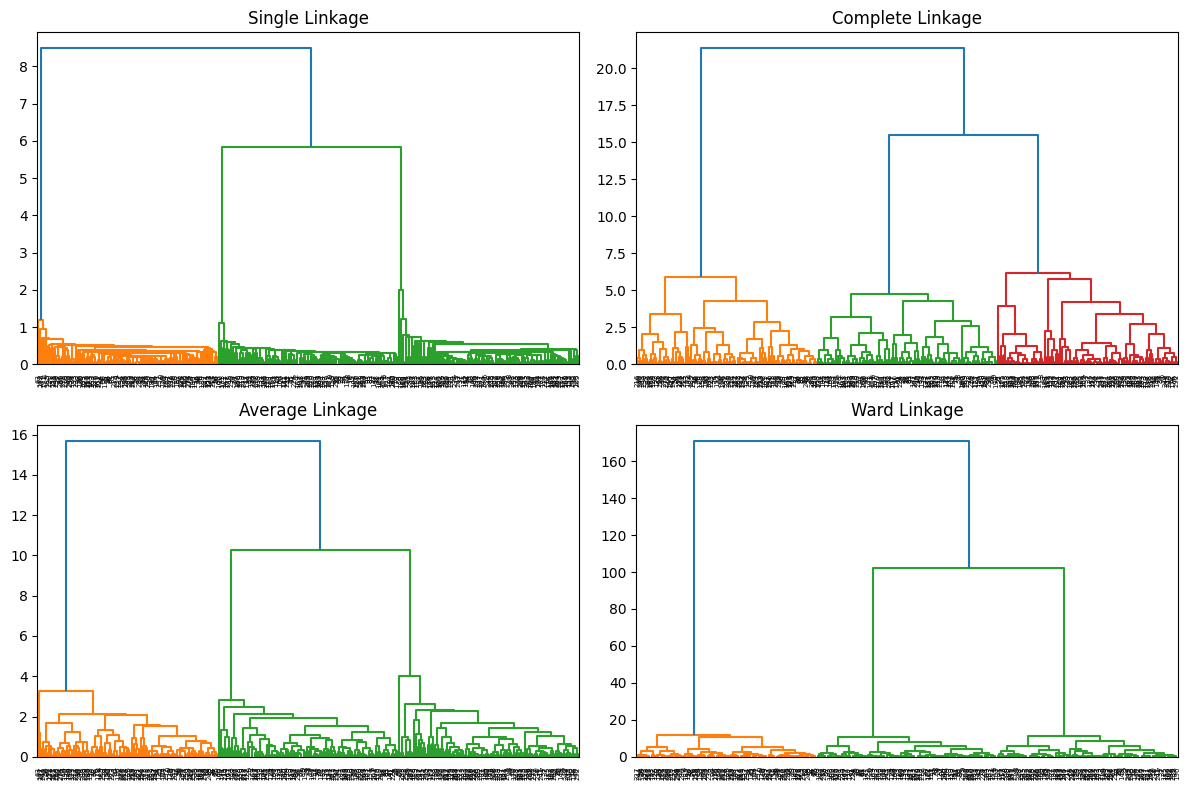

In [3]:

linkage_methods = ['single', 'complete', 'average', 'ward']

plt.figure(figsize=(12,8))

for i, method in enumerate(linkage_methods):

    plt.subplot(2,2,i+1)

    Z = linkage(X, method=method)

    dendrogram(Z)

    plt.title(f"{method.capitalize()} Linkage")

plt.tight_layout()
plt.show()

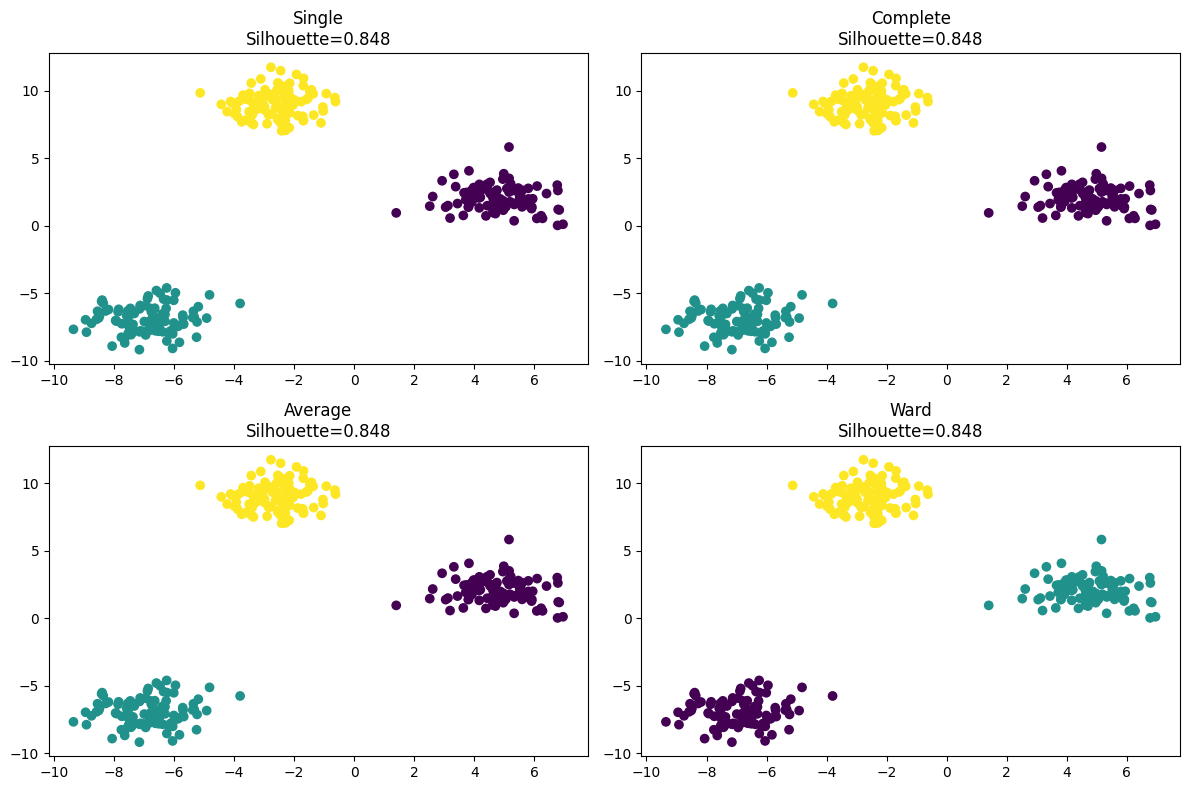

In [4]:
scores = []

fig, axes = plt.subplots(2,2, figsize=(12,8))

for ax, method in zip(axes.flatten(), linkage_methods):

    model = AgglomerativeClustering(
        n_clusters=3,      # chosen from dendrogram
        linkage=method
    )

    labels = model.fit_predict(X)

    score = silhouette_score(X, labels)

    scores.append([method.capitalize(), score])

    ax.scatter(
        X[:,0],
        X[:,1],
        c=labels,
        cmap='viridis'
    )

    ax.set_title(
        f"{method.capitalize()}\nSilhouette={score:.3f}"
    )

plt.tight_layout()
plt.show()



In [5]:


results = pd.DataFrame(
    scores,
    columns=["Linkage Method",
             "Silhouette Score"]
)

print("\nSilhouette Score Comparison")
print(results)


Silhouette Score Comparison
  Linkage Method  Silhouette Score
0         Single           0.84803
1       Complete           0.84803
2        Average           0.84803
3           Ward           0.84803
